In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from glob import glob
import json


In [2]:
experiment_path = (
    "/Users/clairenastaskin/data/2025-07-09/sub-Forest001_ses-20250709_task-audio_run-001/Claire_process/Claire_process_with_registration_regressed_with_motion/"
)
fusi_path = os.path.join(experiment_path, "fUSi_data_after_processing.nii.gz")


fusi_data = nib.load(fusi_path)
fusi_data = fusi_data.get_fdata()

In [3]:
# ##############################################
# # Extract Psychotria time_stamps #
# ##############################################

if os.path.exists(os.path.join(experiment_path, 'task_events.tsv')):
    task_path = os.path.join(experiment_path, 'task_events.tsv')
else:
    task_path = glob(os.path.join(experiment_path, '*events.tsv'))[0]
task_events = pd.read_csv(task_path, sep='\t')

task_events

,trial_type,onset,duration
0,Speech,27.05107,13.0
1,Speech,51.05107,13.0
2,Speech,79.05107,25.0
3,Audio no speech,130.05107,21.0
4,Speech,170.05107,15.0
5,Audio no speech,206.05107,19.0
6,Speech,236.05107,23.0
7,Audio no speech,282.05107,20.0
8,Audio no speech,342.05107,13.0
9,Speech,371.05107,16.0


In [4]:
#############################
# Import Forest1 json info #
############################


Forest1_info_file = os.path.join(experiment_path, "*pwd.json")
# Get the json file path using glob
info_file_path = glob(Forest1_info_file)[0]

# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)

In [13]:
coords = (43,33,14)
radius = 4
timecourse = np.mean(fusi_data[coords[0]-radius:coords[0]+radius,coords[1]-radius:coords[1]+radius,coords[2]-radius:coords[2]+radius,:],axis=(0,1,2))
np.save(
    os.path.join(experiment_path, f"time_course_coord_{coords[0]}-{coords[1]}-{coords[2]}_radius{radius}.npy"),
    timecourse
)
print(timecourse.shape)

(537,)


In [14]:
power_doppler_time_course = pd.DataFrame(
    {
        "timestamp": frame_times,
        "power_doppler_value": timecourse,
    }
)

In [15]:
task_list_type = task_events.trial_type.unique()
print(task_list_type)

['Speech' 'Audio no speech']


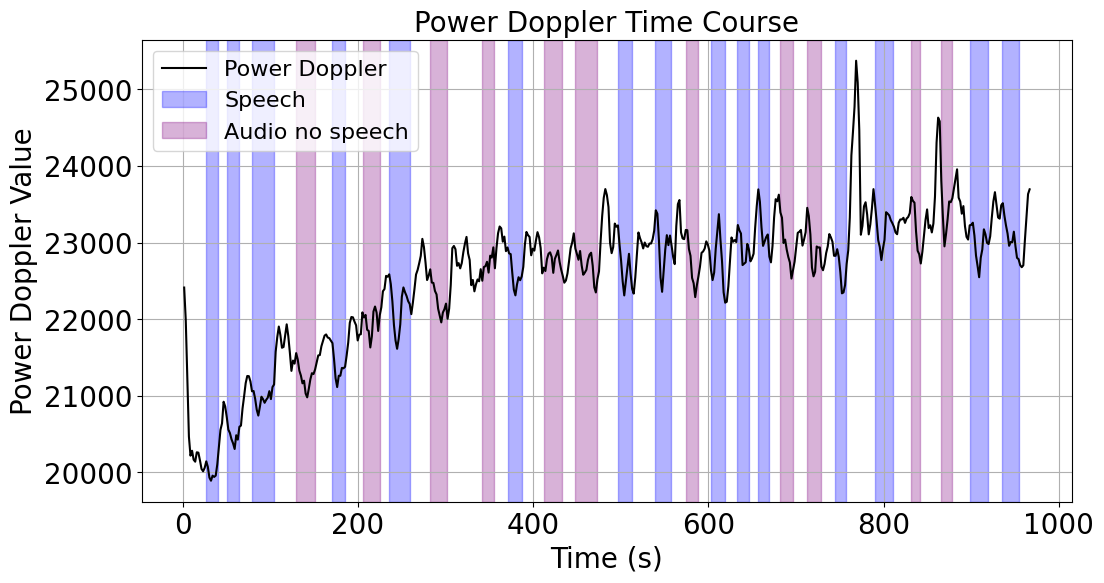

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(
    power_doppler_time_course.timestamp,
    power_doppler_time_course.power_doppler_value,
    color="black",
    label="Power Doppler"
)

task_colors = ['blue','purple', 'gray', 'lightgreen','red','orange','yellow','pink']

# Add colored rectangles for stimulus periods
for task_index in range(len(task_list_type)):
    task = task_list_type[task_index]
    task_events_timing = pd.DataFrame()
    task_events_timing["Event"] = ["start", "stop"] * len(
        task_events[task_events["trial_type"] == task]
    )
    task_events_timing["Timestamp"] = [
        onset
        for onset, duration in zip(
            task_events[task_events["trial_type"] == task]["onset"],
            task_events[task_events["trial_type"] == task]["duration"],
        )
        for _ in range(2)
    ]
    task_events_timing.loc[task_events_timing["Event"] == "stop", "Timestamp"] += (
        task_events[task_events["trial_type"] == task]["duration"].values.repeat(1)
    )
    task_events_timing = task_events_timing.sort_values("Timestamp").reset_index(drop=True)
    start_times = task_events_timing[task_events_timing["Event"] == "start"]["Timestamp"]
    stop_times = task_events_timing[task_events_timing["Event"] == "stop"]["Timestamp"]
    for start, stop in zip(start_times, stop_times):
        plt.axvspan(start, stop, color=task_colors[task_index], alpha=0.3, label=task if start == start_times.iloc[0] else "")

plt.xlabel("Time (s)", fontsize=20)
plt.ylabel("Power Doppler Value", fontsize=20)
plt.title("Power Doppler Time Course", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.ylim(17000, 22000)
plt.grid(True)
plt.legend(fontsize=16)
plt.show()

